# 1: Init

In [1]:
import pandas as pd
from gerrychain import (Partition, Graph, updaters, MarkovChain, constraints, accept)
from gerrychain.proposals import recom
from gerrychain.constraints import contiguous
from gerrychain.updaters import cut_edges
from functools import partial
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np

MARKOV_STEPS = 10_000

# 2: Functions

In [2]:
def plot_partition(partition, graph, title=None):
    partition_colors = {
        '1':'blue',
        '2':'green',
        '3':'purple',
        '4':'orange',
        '5':'hotpink',
        '6':'yellow',
        '7':'black',
        '8':'red',
        '9': 'white',
        '10': 'grey',
        '11': 'magenta',
        '12': 'teal',
        '13': 'olive',
        '14': 'brown',
        '15': 'navy',
        '16': 'lime'
    }
    node_positions = {}
    node_labels = {}
    node_colors = []
    for node_id, node_attrs in graph.nodes.items():
        node_positions[node_id] = (node_attrs['x'], node_attrs['y'])
        partition_id = str(partition.assignment[node_id])
        node_labels[node_id] = partition_id
        node_colors.append(partition_colors[partition_id])
    
    fig, ax = plt.subplots(figsize=(8, 8))
    nx.draw(graph, with_labels=True, labels=node_labels, pos=node_positions, node_color=node_colors, ax=ax)
    if title:
        ax.set_title(title, fontsize=16)
    plt.show()

def extract_data(partition):
    data_rows = []
    
    for node_id in partition.graph.nodes:
        node = partition.graph.nodes[node_id]
        assigned_dist = partition.assignment[node_id] 
        pop = node.get('TOTPOP', 1)
        
        if 'muni' in node:
            data_rows.append({'category': 'muni', 'community_id': f"muni_{node['muni']}", 'district': assigned_dist, 'pop': pop})
        if 'county' in node:
            data_rows.append({'category': 'county', 'community_id': f"county_{node['county']}", 'district': assigned_dist, 'pop': pop})
        if 'water_dist' in node:
            data_rows.append({'category': 'water', 'community_id': f"water_{node['water_dist']}", 'district': assigned_dist, 'pop': pop})
            
    return pd.DataFrame(data_rows)

def score_communities(raw_df):
    """
    calculates the sum of squared shares for each community

    inputs:
        raw_df: df with cols: category, community_id, district, pop
    outputs:
        communities_scores: df with cols: category, community_id, total_pop, sss_score
    """
    # get total pop per community (water1, water2..)
    total_pops = raw_df.groupby(['category', 'community_id'])['pop'].sum().reset_index()
    total_pops.rename(columns={'pop': 'total_pop'}, inplace=True)

    # get pop per community and district
    district_splits = raw_df.groupby(['category', 'community_id', 'district'])['pop'].sum().reset_index()

    # merge to get pop / total pop
    merged = pd.merge(district_splits, total_pops, on=['category', 'community_id'])

    # get squared shares
    merged['share'] = merged['pop'] / merged['total_pop']
    merged['squared_share'] = merged['share'] ** 2

    # sum squared shares across all communities in each category
    # this is the 'final' score for each community (not grouped yet)
    final_sss_df = merged.groupby(['category', 'community_id', 'total_pop'])['squared_share'].sum().reset_index()
    final_sss_df.rename(columns={'squared_share': 'sss_score'}, inplace=True)
    return final_sss_df

def score_overall(dataframe, weights):
    """
    calculates the total coi preservation as a single metric between 0 and 1

    inputs:
        dataframe: output from score_communities()
        weights: dict with keys: category, values: weight
    outputs:
        final_score: total coi preservation (tcp) between 0 and 1
    """
    # after getting sss score for each community, we want 1 final metric
    # bigger populations need more weight in category averages
    # get pop weighted avg for each community - sum(pop[i] * coi score / category pop
    dataframe['weighted_score'] = dataframe['sss_score'] * dataframe['total_pop']
    category_score_sums = dataframe.groupby('category')['weighted_score'].sum()
    category_pop_sums = dataframe.groupby('category')['total_pop'].sum()

    # gets our category averages
    pop_weighted_avg = category_score_sums / category_pop_sums
    # multiply each category score by weight and sum for final metric
    final_score = (pop_weighted_avg * pd.Series(weights)).sum()
    return final_score

def calculate_tcp(partition):
    # arbitrary
    weights = {'water': 0.5, 'county': 0.3, 'muni': 0.2}

    raw_df = extract_data(partition)
    community_scores = score_communities(raw_df)
    final_score = score_overall(community_scores, weights)
    
    return final_score

def count_mcure_wins(partition):
    mcure_wins = 0
    for district_id, node_ids in partition.parts.items():
        mcure_pop = 0
        tot_pop = 0
        for node_id in node_ids:
            # grab node info
            node_attrs = partition.graph.nodes[node_id]
            # get vote pop and total pop
            mcure_pop += node_attrs['MCURE']
            tot_pop += node_attrs['TOTPOP']
            
        if mcure_pop / tot_pop > 0.5:
            mcure_wins += 1

    return mcure_wins


# 3: Init Graph and Markov Chain

In [3]:
## init
g = Graph.from_json('data/gerrymandria_randomvotes.json')
initial_partition = Partition(
    g, 
    assignment="district", 
    updaters={ 
        'tcp_score': calculate_tcp,
        'cut_edges': cut_edges,
        'mcure_wins': count_mcure_wins
    }
)

## chaining
total_population = sum(node.get('TOTPOP', 1) for node in g.nodes.values())
target_pop = total_population / len(initial_partition.parts)

proposal = partial(recom, pop_col="TOTPOP", pop_target=target_pop, epsilon=0.05, node_repeats=2)
chain = MarkovChain(
    proposal=proposal,
    constraints=[contiguous],
    accept=accept.always_accept,
    initial_state=initial_partition,
    total_steps=MARKOV_STEPS
)

# 4: Run Markov Chain

In [4]:
## run chain and collect scores
tcp_scores = []
cut_edges_count = []
mcure_wins_count = []
best_score=0
best_map=None
worst_score=1
worst_map=None
overall_best_score=0
overall_best_map=None
most_seats=0

for partition in chain:
    score = partition['tcp_score']
    cuts = len(partition['cut_edges'])
    seats = partition['mcure_wins']

    tcp_scores.append(score)
    cut_edges_count.append(cuts)
    mcure_wins_count.append(seats)

    # track most preserved
    if score > best_score:
        best_score = score
        best_map = partition
        
    # track least preserved
    if score < worst_score:
        worst_score = score
        worst_map = partition

    # track overall best
    if seats > most_seats:
        most_seats = seats
        overall_best_score = score
        overall_best_map = partition
    elif seats == most_seats:
        if score > overall_best_score:
            overall_best_score = score
            overall_best_map = partition

# Graphing

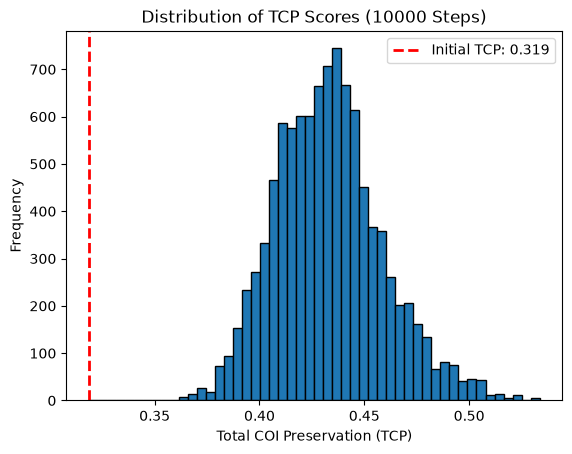

In [5]:
# hist: tcp scores distribution
plt.hist(tcp_scores, bins=50, edgecolor="black")
initial_score = initial_partition["tcp_score"]
plt.axvline(
    initial_score,
    color="red",
    linestyle="dashed",
    linewidth=2,
    label=f"Initial TCP: {initial_score:.3f}",
)

plt.title(f"Distribution of TCP Scores ({MARKOV_STEPS} Steps)")
plt.xlabel("Total COI Preservation (TCP)")
plt.ylabel("Frequency")
plt.legend()
plt.show()



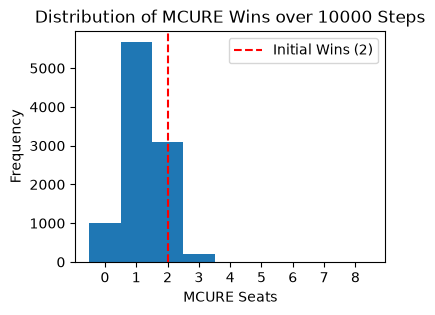

In [6]:
# hist: mcure seats distribution
n_districts = len(initial_partition.parts)
plt.figure(figsize=(4,3))
plt.hist(
    mcure_wins_count, 
    bins=np.arange(-0.5, n_districts + 1.5, 1)
    )
plt.xticks(range(n_districts + 1))
plt.xlabel("MCURE Seats")
plt.ylabel("Frequency")
plt.title(f"Distribution of MCURE Wins over {MARKOV_STEPS} Steps")

# initial wins line
initial_wins = count_mcure_wins(initial_partition)
plt.axvline(x=initial_wins, color='red', linestyle='dashed', label=f'Initial Wins ({initial_wins})')

plt.legend()
plt.show()

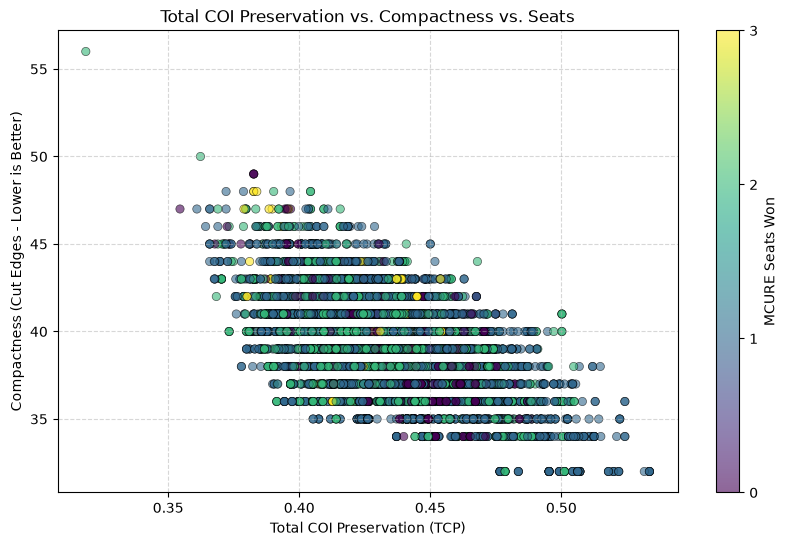

In [7]:
# scatter: tcp vs compactness vs seats
plt.figure(figsize=(10, 6))
scatter = plt.scatter(
    tcp_scores, 
    cut_edges_count, 
    c=mcure_wins_count, 
    cmap='viridis',
    alpha=0.6, 
    edgecolor='black',
    linewidth=0.5
)

cbar = plt.colorbar(scatter)
cbar.set_label('MCURE Seats Won')
cbar.set_ticks(range(min(mcure_wins_count), max(mcure_wins_count)+1))

plt.title('Total COI Preservation vs. Compactness vs. Seats')
plt.xlabel('Total COI Preservation (TCP)')
plt.ylabel('Compactness (Cut Edges - Lower is Better)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

plotting most preserved map:
tcp score: 0.534
cut edges: 32
mcure seats won: 1/8


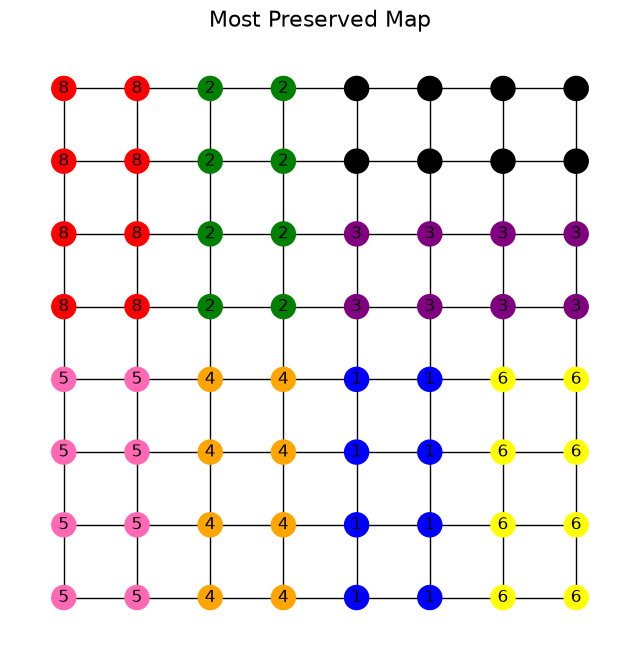

plotting least preserved map:
tcp score: 0.319
cut edges: 56
mcure seats won: 2/8


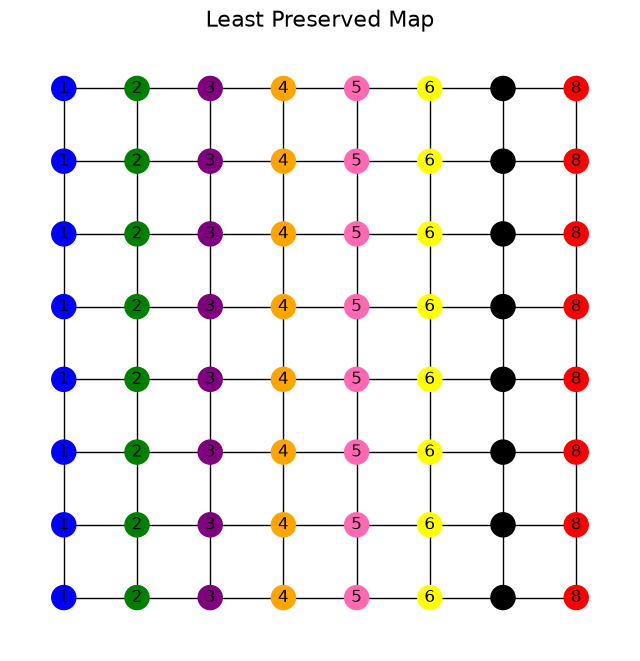

plotting best max representation map:
tcp score: 0.470
cut edges: 37
mcure seats won: 3/8


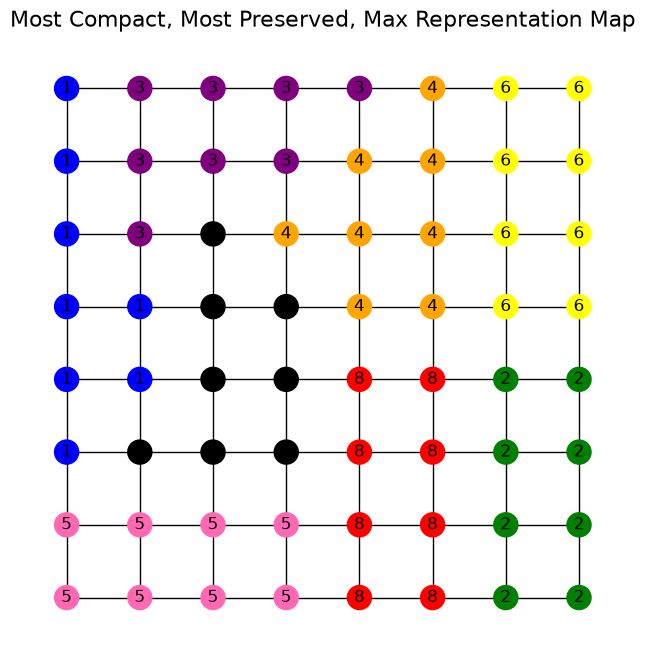

In [8]:
# plotted partition maps
print("plotting most preserved map:")
print(f"tcp score: {best_map['tcp_score']:.3f}")
print(f"cut edges: {len(best_map['cut_edges'])}")
print(f"mcure seats won: {best_map['mcure_wins']}/8")
plot_partition(best_map, g, 'Most Preserved Map')

print("plotting least preserved map:")
print(f"tcp score: {worst_map['tcp_score']:.3f}")
print(f"cut edges: {len(worst_map['cut_edges'])}")
print(f"mcure seats won: {worst_map['mcure_wins']}/8")
plot_partition(worst_map, g, 'Least Preserved Map')

print("plotting best max representation map:")
print(f"tcp score: {overall_best_map['tcp_score']:.3f}")
print(f"cut edges: {len(overall_best_map['cut_edges'])}")
print(f"mcure seats won: {overall_best_map['mcure_wins']}/8")
plot_partition(overall_best_map, g, 'Most Compact, Most Preserved, Max Representation Map')